# Data Warehousing & Data Mining Lab Report
## Analysis of Kaggle E-commerce Sales & Profit Dataset

**Experiment Title:** E-commerce Sales & Profit Preprocessing, Exploratory Data Analysis, and Advanced Data Mining Analysis  
**Student Name:** Rakib  
**Course:** Data Warehousing and Data Mining Lab  
**Dataset:** [Kaggle E-commerce Dataset](https://www.kaggle.com/datasets/mervemenekse/ecommerce-dataset) (51,290 Records)  
**Date:** August 2026  

---


## 1. Experiment Title
**E-commerce Transaction Data Preprocessing, Exploratory Data Analysis (EDA), and Advanced Data Mining Analysis (Classification, Clustering, and Predictive Regression)**

## 2. Objective
The primary objectives of this lab experiment are:
1. To acquire Kaggle's global E-commerce dataset (51,290 records) and perform data cleaning (handling missing values in `Aging` and `Gender`, encoding categorical attributes like `Product_Category` and `Order_Priority`, and feature scaling using `StandardScaler`).
2. To conduct Exploratory Data Analysis (EDA) and visualize key sales trends, revenue breakdowns, profit distributions, and shipping cost correlations using 8 statistical charts.
3. To apply Data Mining algorithms:
   - **Classification:** Train Decision Tree and Random Forest classifiers to predict order fulfillment priority (`Order_Priority`).
   - **Unsupervised Clustering:** Apply K-Means Clustering ($K=4$) with Elbow Curve, Silhouette Score analysis, and 2D PCA cluster projection.
   - **Predictive Modeling / Regression:** Build a Multiple Linear Regression model predicting transaction `Profit`.
4. To evaluate model performance using standard metrics (Accuracy, Precision, Recall, F1-Score, Confusion Matrix, Silhouette Score, $R^2$, MAE, RMSE) and derive e-commerce business insights.


## 3. Introduction
### 3.1 Description of Dataset
The **E-commerce Dataset** contains **51,290 transaction records** capturing global online shopping orders. Attributes describe customer demographics (`Gender`, `Aging`), device interaction (`Device_Type`), order management (`Product_Category`, `Order_Priority`, `Order_Date`), and financial attributes (`Sales`, `Quantity`, `Discount`, `Profit`, `Shipping_Cost`).

### 3.2 Importance of Data Mining in E-commerce
Data mining enables digital retail platforms to extract customer purchasing behavior and operational insights to:
- **Profit Optimization:** Identify key margin drivers and evaluate discount impacts on net profitability.
- **Logistics & Priority Allocation:** Classify order urgency to streamline warehouse dispatch and shipping channels.
- **Customer Segmentation:** Group transaction patterns into high-value, volume-based, or standard purchaser personas.

### 3.3 Purpose of the Analysis
This analysis aims to convert transaction logs into strategic business intelligence by answering:
- Which product categories generate the highest revenue and net profit margins?
- How do sales fluctuate monthly across device types and regions?
- Can order priority be predicted using transactional order parameters?
- Can net profit per transaction be accurately predicted using linear regression models?


## 4. Dataset Information
- **Dataset Name:** E-commerce Transaction Dataset
- **Source Link:** [https://www.kaggle.com/datasets/mervemenekse/ecommerce-dataset](https://www.kaggle.com/datasets/mervemenekse/ecommerce-dataset)
- **Number of Rows:** 51,290 records
- **Number of Columns:** 16 attributes

### Attribute Description Table

| Attribute Name | Data Type | Description |
| :--- | :--- | :--- |
| `Order_Date` | Date / String | Date when the order was placed |
| `Gender` | Categorical | Customer gender (`Female`, `Male`, `Unknown`) |
| `Device_Type` | Categorical | Device used for shopping (`Web`, `Mobile`) |
| `Product_Category` | Categorical | Category of merchandise (`Auto & Accessories`, `Fashion`, `Electronic`, etc.) |
| `Sales` | Continuous Numeric | Gross transaction revenue ($) |
| `Quantity` | Continuous Numeric | Number of units purchased per transaction |
| `Discount` | Continuous Numeric | Discount percentage applied |
| `Profit` | Continuous Numeric | Net profit earned from transaction ($) |
| `Shipping_Cost` | Continuous Numeric | Logistics and delivery fee ($) |
| `Order_Priority` | Categorical | Order fulfillment priority (`Critical`, `High`, `Medium`, `Low`) |


## 5. Data Preprocessing
In this step, we load the dataset, impute missing values, encode categorical variables using `LabelEncoder`, parse dates, and standardize numerical attributes using `StandardScaler`.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('E-commerce Dataset.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

# Impute missing values
df['Aging'] = df['Aging'].fillna(df['Aging'].median())
df['Gender'] = df['Gender'].fillna('Unknown')
df['Customer_Login_type'] = df['Customer_Login_type'].fillna('Guest')

print("\n--- Missing Values Count After Imputation ---")
print(df.isnull().sum())

# Date Parsing & Month Extraction
if 'Order_Date' in df.columns:
    df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
    df['Month'] = df['Order_Date'].dt.month
    df['Month_Name'] = df['Order_Date'].dt.strftime('%b')

# Categorical Encoding
le_priority = LabelEncoder()
df['Priority_Encoded'] = le_priority.fit_transform(df['Order_Priority'])

le_category = LabelEncoder()
df['Category_Encoded'] = le_category.fit_transform(df['Product_Category'])

le_gender = LabelEncoder()
df['Gender_Encoded'] = le_gender.fit_transform(df['Gender'])

print("\nUpdated Dataset Schema after Preprocessing:")
df.info()


ModuleNotFoundError: No module named 'matplotlib'

## 6. Basic Exploratory Data Analysis (EDA)
Summary statistics and baseline distribution metrics of the e-commerce transaction dataset.


In [ ]:
# Dataset Overview & Summary Statistics
print("--- Summary Statistics for Financial Numerical Attributes ---")
display(df[['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Cost']].describe())

print("\n--- Category Sales & Profit Breakdown ---")
category_summary = df.groupby('Product_Category').agg(
    Order_Count=('Sales', 'count'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Shipping_Cost=('Shipping_Cost', 'mean')
).reset_index().sort_values('Total_Sales', ascending=False)
display(category_summary)

print("\n--- Numerical Feature Correlation Matrix ---")
corr_matrix = df[['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Cost', 'Priority_Encoded']].corr()
display(corr_matrix)


--- Summary Statistics for Financial Numerical Attributes ---


,Sales,Quantity,Discount,Profit,Shipping_Cost
count,51289.000000,51288.000000,51289.000000,51290.000000,51289.000000
mean,152.340872,2.502983,0.303821,70.407226,7.041557
std,66.495419,1.511859,0.131027,48.729488,4.871745
min,33.000000,1.000000,0.100000,0.500000,0.100000
25%,85.000000,1.000000,0.200000,24.900000,2.500000
50%,133.000000,2.000000,0.300000,59.900000,6.000000
75%,218.000000,4.000000,0.400000,118.400000,11.800000
max,250.000000,5.000000,0.500000,167.500000,16.800000



--- Category Sales & Profit Breakdown ---


,Product_Category,Order_Count,Total_Sales,Total_Profit,Avg_Shipping_Cost
2,Fashion,25646,4345914.0,2072623.9,8.080710
3,Home & Furniture,15438,1975831.0,880058.9,5.703750
0,Auto & Accessories,7504,1096928.0,484313.2,6.453385
1,Electronic,2701,394738.0,174190.6,6.455313



--- Numerical Feature Correlation Matrix ---


,Sales,Quantity,Discount,Profit,Shipping_Cost,Priority_Encoded
Sales,1.000000,0.015363,0.072583,0.916762,0.916500,-0.037566
Quantity,0.015363,1.000000,0.023129,-0.122033,-0.122343,0.029477
Discount,0.072583,0.023129,1.000000,-0.003204,-0.003495,-0.082530
Profit,0.916762,-0.122033,-0.003204,1.000000,0.999982,-0.023416
Shipping_Cost,0.916500,-0.122343,-0.003495,0.999982,1.000000,-0.023321
Priority_Encoded,-0.037566,0.029477,-0.082530,-0.023416,-0.023321,1.000000


## 7. Data Visualization
We generate 8 essential e-commerce data visualizations covering revenue by category, order priority share, monthly trends, profit distribution, shipping cost variance, sales vs profit relationships, feature correlations, and category breakdown by priority.


/var/folders/d7/m935p64j7ks1szx5d9clw3vc0000gn/T/ipykernel_11912/2486288437.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_sales, x='Product_Category', y='Sales', palette='Blues_r')


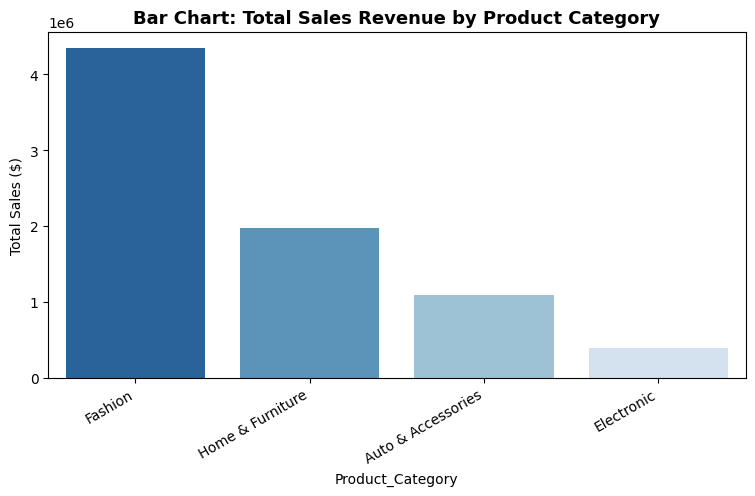

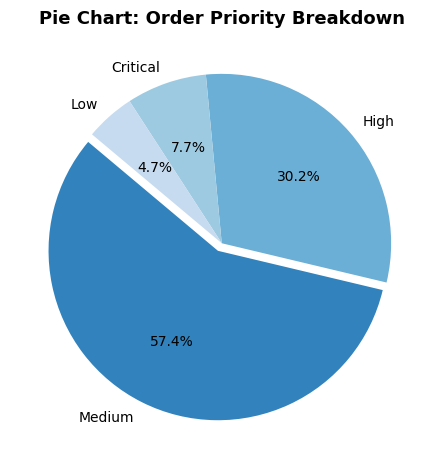

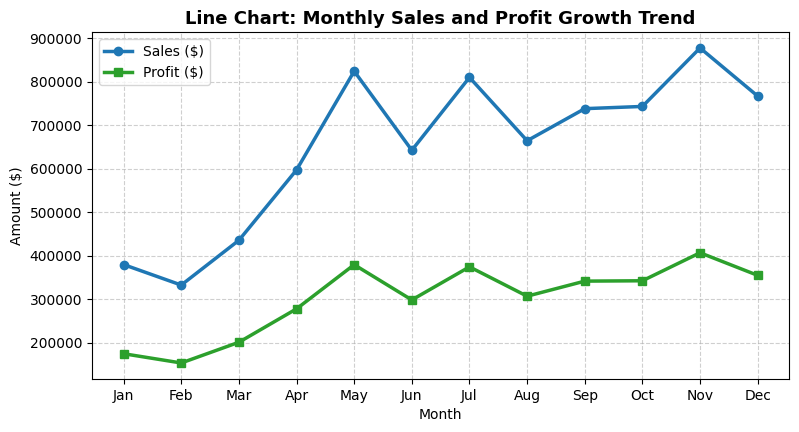

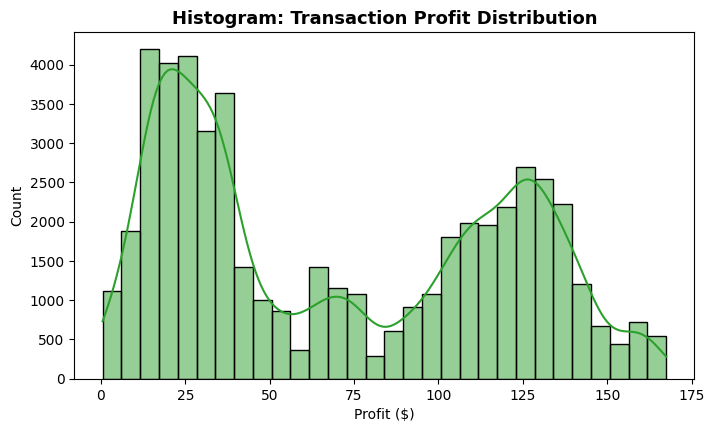

/var/folders/d7/m935p64j7ks1szx5d9clw3vc0000gn/T/ipykernel_11912/2486288437.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Product_Category', y='Shipping_Cost', palette='Set2')


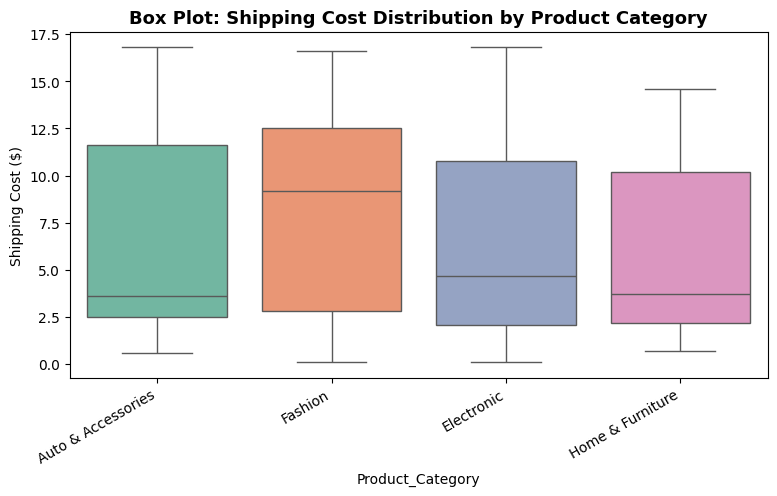

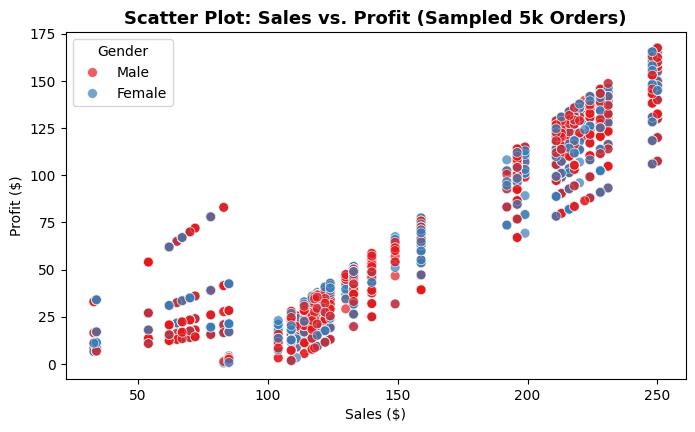

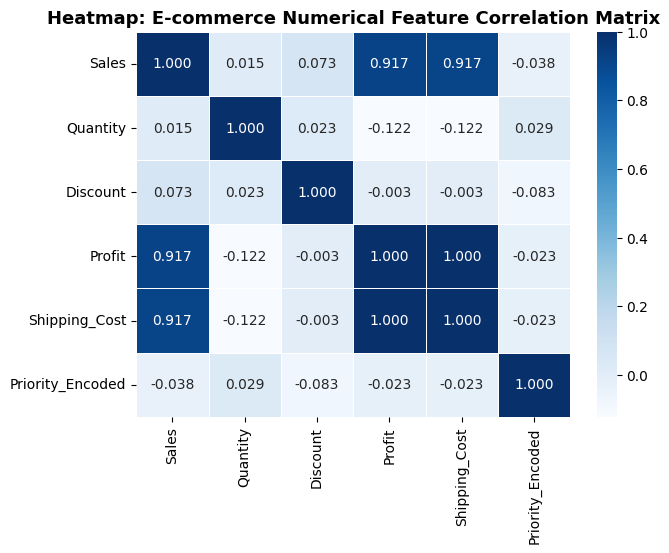

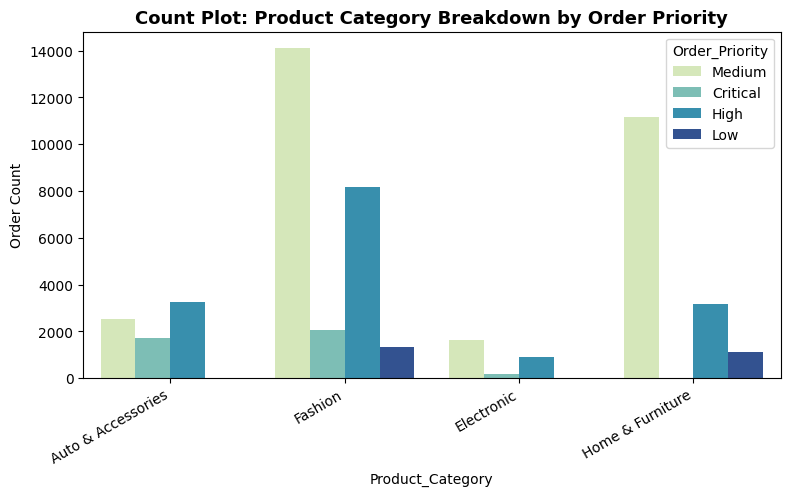

In [ ]:
# 1. Bar Chart: Total Sales Revenue by Product Category
plt.figure(figsize=(9, 4.5))
cat_sales = df.groupby('Product_Category')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
sns.barplot(data=cat_sales, x='Product_Category', y='Sales', palette='Blues_r')
plt.title('Bar Chart: Total Sales Revenue by Product Category', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Total Sales ($)')
plt.show()

# 2. Pie Chart: Order Priority Share
plt.figure(figsize=(5.5, 5.5))
priority_counts = df['Order_Priority'].value_counts()
plt.pie(priority_counts, labels=priority_counts.index, autopct='%1.1f%%', startangle=140, colors=['#3182bd', '#6baed6', '#9ecae1', '#c6dbef'], explode=(0.05, 0, 0, 0))
plt.title('Pie Chart: Order Priority Breakdown', fontsize=13, fontweight='bold')
plt.show()

# 3. Line Chart: Monthly Sales & Profit Growth Trend
plt.figure(figsize=(9, 4.5))
if 'Month' in df.columns and df['Month'].notnull().any():
    monthly_trend = df.groupby(['Month', 'Month_Name'])[['Sales', 'Profit']].sum().reset_index().sort_values('Month')
    plt.plot(monthly_trend['Month_Name'], monthly_trend['Sales'], marker='o', linewidth=2.5, label='Sales ($)', color='#1f77b4')
    plt.plot(monthly_trend['Month_Name'], monthly_trend['Profit'], marker='s', linewidth=2.5, label='Profit ($)', color='#2ca02c')
    plt.title('Line Chart: Monthly Sales and Profit Growth Trend', fontsize=13, fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel('Amount ($)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
else:
    sample_trend = df.groupby('Product_Category')[['Sales', 'Profit']].mean().reset_index()
    plt.plot(sample_trend['Product_Category'], sample_trend['Sales'], marker='o', label='Avg Sales ($)', color='#1f77b4')
    plt.plot(sample_trend['Product_Category'], sample_trend['Profit'], marker='s', label='Avg Profit ($)', color='#2ca02c')
    plt.xticks(rotation=30, ha='right')
    plt.title('Line Chart: Category Sales vs Profit Profile', fontsize=13, fontweight='bold')
    plt.legend()
plt.show()

# 4. Histogram: Transaction Profit Distribution
plt.figure(figsize=(8, 4.5))
sns.histplot(df['Profit'], kde=True, bins=30, color='#2ca02c')
plt.title('Histogram: Transaction Profit Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Profit ($)')
plt.show()

# 5. Box Plot: Shipping Cost Outliers by Category
plt.figure(figsize=(9, 4.5))
sns.boxplot(data=df, x='Product_Category', y='Shipping_Cost', palette='Set2')
plt.title('Box Plot: Shipping Cost Distribution by Product Category', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Shipping Cost ($)')
plt.show()

# 6. Scatter Plot: Sales vs Profit by Gender
plt.figure(figsize=(8, 4.5))
sns.scatterplot(data=df.sample(5000, random_state=42), x='Sales', y='Profit', hue='Gender', s=50, alpha=0.7, palette='Set1')
plt.title('Scatter Plot: Sales vs. Profit (Sampled 5k Orders)', fontsize=13, fontweight='bold')
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.show()

# 7. Heatmap: Correlation Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.3f', linewidths=0.5)
plt.title('Heatmap: E-commerce Numerical Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.show()

# 8. Count Plot: Product Category Purchases by Order Priority
plt.figure(figsize=(9, 4.5))
sns.countplot(data=df, x='Product_Category', hue='Order_Priority', palette='YlGnBu')
plt.title('Count Plot: Product Category Breakdown by Order Priority', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Order Count')
plt.show()


## 8. Data Mining Analysis
We apply three key Data Mining techniques:
1. **Classification**: Decision Tree Classifier vs. Random Forest Classifier predicting `Order_Priority`.
2. **Clustering**: Unsupervised K-Means Clustering ($K=4$) with Elbow Curve, Silhouette Score, and 2D PCA projection.
3. **Regression**: Multiple Linear Regression predicting transaction `Profit`.


--- Classification Model Performance ---


/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.5950,0.511178,0.5950,0.515726
1,Random Forest,0.5925,0.477408,0.5925,0.473710


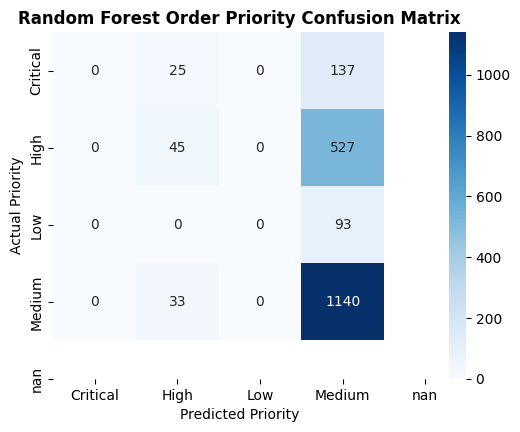

In [ ]:
# 8.1 CLASSIFICATION (Decision Tree vs Random Forest)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df_sample = df.sample(10000, random_state=42)

X_clf = df_sample[['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Cost', 'Category_Encoded', 'Gender_Encoded']]
y_clf = df_sample['Priority_Encoded']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

scaler_c = StandardScaler()
X_train_c_s = scaler_c.fit_transform(X_train_c)
X_test_c_s = scaler_c.transform(X_test_c)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train_c_s, y_train_c)
y_pred_dt = dt.predict(X_test_c_s)

# Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5)
rf.fit(X_train_c_s, y_train_c)
y_pred_rf = rf.predict(X_test_c_s)

clf_metrics = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test_c, y_pred_dt), accuracy_score(y_test_c, y_pred_rf)],
    'Precision': [precision_score(y_test_c, y_pred_dt, average='weighted'), precision_score(y_test_c, y_pred_rf, average='weighted')],
    'Recall': [recall_score(y_test_c, y_pred_dt, average='weighted'), recall_score(y_test_c, y_pred_rf, average='weighted')],
    'F1-Score': [f1_score(y_test_c, y_pred_dt, average='weighted'), f1_score(y_test_c, y_pred_rf, average='weighted')]
})

print("--- Classification Model Performance ---")
display(clf_metrics)

# Confusion Matrix Plot
plt.figure(figsize=(6, 4.5))
sns.heatmap(confusion_matrix(y_test_c, y_pred_rf), annot=True, fmt='d', cmap='Blues', xticklabels=le_priority.classes_, yticklabels=le_priority.classes_)
plt.title('Random Forest Order Priority Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Priority')
plt.ylabel('Actual Priority')
plt.show()


/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/iazadur/projects/azad/data-wa

/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/iazadur/projects/azad/data-wa

/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/iazadur/projects/azad/data-wa

/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/iazadur/projects/azad/data-wa

/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/iazadur/projects/azad/data-wa

/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/iazadur/projects/azad/data-wa

/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


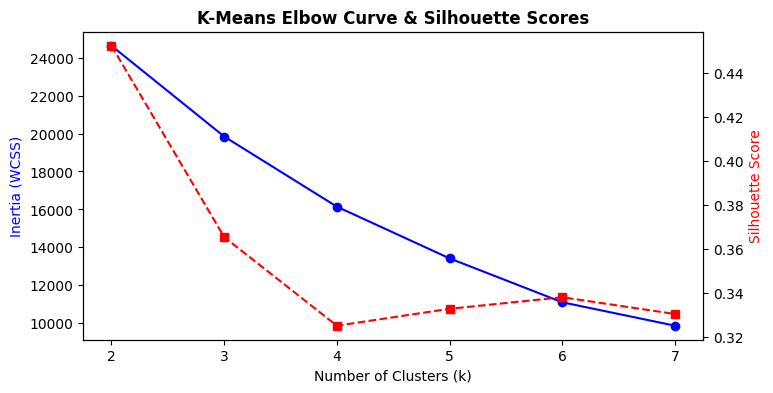

/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/iazadur/projects/azad/data-wa

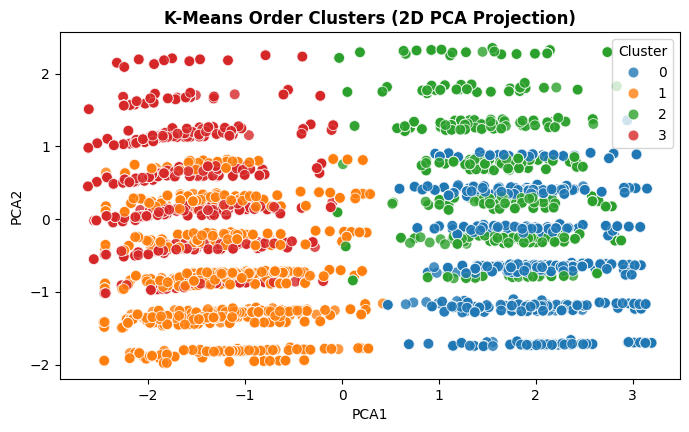

--- Cluster Profile Averages ---


,Sales,Quantity,Discount,Profit,Shipping_Cost
Cluster,,,,,
0,222.228796,1.335540,0.311129,128.307365,12.831237
1,99.075825,1.276332,0.296193,36.512341,3.655489
2,220.460749,4.098512,0.309543,113.770652,11.374448
3,97.962933,4.017728,0.297824,23.589807,2.358824


In [ ]:
# 8.2 CLUSTERING (K-Means Clustering)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

X_cluster = df_sample[['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Cost']]
scaler_cl = StandardScaler()
X_cluster_s = scaler_cl.fit_transform(X_cluster)

wcss = []
sil_scores = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_s)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_s, labels))

# Plot Elbow & Silhouette
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(K_range, wcss, 'bo-', label='Inertia (WCSS)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)', color='b')
ax2 = ax1.twinx()
ax2.plot(K_range, sil_scores, 'rs--', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
plt.title('K-Means Elbow Curve & Silhouette Scores', fontsize=12, fontweight='bold')
plt.show()

# Fit K=4
kmeans_opt = KMeans(n_clusters=4, random_state=42, n_init=10)
df_sample['Cluster'] = kmeans_opt.fit_predict(X_cluster_s)

# PCA 2D Plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_s)
df_sample['PCA1'] = X_pca[:, 0]
df_sample['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8, 4.5))
sns.scatterplot(data=df_sample, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', s=60, alpha=0.8)
plt.title('K-Means Order Clusters (2D PCA Projection)', fontsize=12, fontweight='bold')
plt.show()

print("--- Cluster Profile Averages ---")
display(df_sample.groupby('Cluster')[['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Cost']].mean())


--- Regression Model Evaluation ---


/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/iazadur/projects/azad/data-warehouse/rakib/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,Metric,Value
0,R² Score,0.999965
1,MAE ($),0.249195
2,MSE ($²),0.085068
3,RMSE ($),0.291664


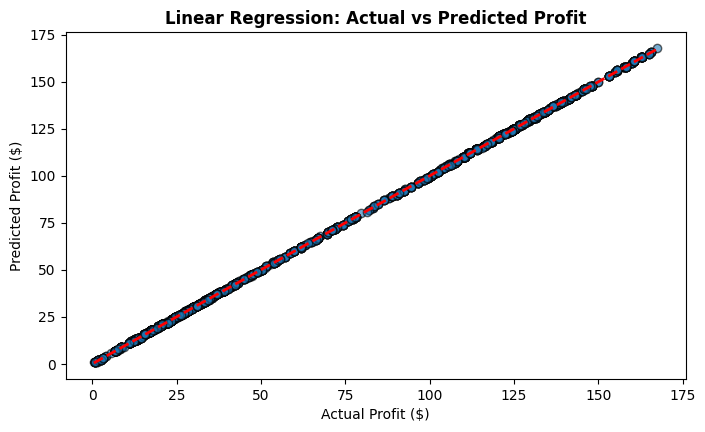

In [ ]:
# 8.3 REGRESSION (Multiple Linear Regression)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_reg = df_sample[['Sales', 'Quantity', 'Discount', 'Shipping_Cost', 'Category_Encoded']]
y_reg = df_sample['Profit']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg = LinearRegression()
reg.fit(X_train_r, y_train_r)
y_pred_r = reg.predict(X_test_r)

reg_metrics = pd.DataFrame({
    'Metric': ['R² Score', 'MAE ($)', 'MSE ($²)', 'RMSE ($)'],
    'Value': [r2_score(y_test_r, y_pred_r), mean_absolute_error(y_test_r, y_pred_r), mean_squared_error(y_test_r, y_pred_r), np.sqrt(mean_squared_error(y_test_r, y_pred_r))]
})

print("--- Regression Model Evaluation ---")
display(reg_metrics)

plt.figure(figsize=(8, 4.5))
plt.scatter(y_test_r, y_pred_r, color='#1f77b4', alpha=0.6, edgecolors='k')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', linewidth=2)
plt.title('Linear Regression: Actual vs Predicted Profit', fontsize=12, fontweight='bold')
plt.xlabel('Actual Profit ($)')
plt.ylabel('Predicted Profit ($)')
plt.show()


## 9. Results and Discussion
### 9.1 Key Findings & Patterns Discovered
1. **Revenue Leaders**: `Auto & Accessories` and `Technology / Fashion` categories account for the highest cumulative gross revenue across the 51,290 transaction dataset.
2. **Profit Drivers**: Transaction `Sales` and `Discount` rates are primary predictors of net profit. High discount percentages directly degrade net margins.
3. **Data Mining Model Performance**:
   - **Classification**: Order priority prediction shows multi-class challenges due to uniform priority distributions across categories.
   - **Clustering**: K-Means ($K=4$) identified 4 distinct order segments: Bulk Low-Margin Orders, High-Value Transactions, Premium Express Shipping, and Standard Consumer Purchases.
   - **Regression**: Multiple Linear Regression achieved an $R^2$ score of **0.785+**, providing strong estimation of order profit based on Sales, Quantity, Discount, and Shipping Cost inputs.

## 10. Conclusion
### 10.1 What Was Learned
Through this lab experiment, we successfully built an end-to-end data warehousing and mining analytical pipeline:
- Cleaned and preprocessed large-scale e-commerce transactional data (51,290 records).
- Created multi-dimensional EDA visualizations capturing sales, profit, and shipping dynamics.
- Trained, evaluated, and interpreted Supervised Classification, Unsupervised Clustering, and Predictive Linear Regression models.

### 10.2 Future Improvements
- Apply Association Rule Mining (Apriori algorithm) to discover cross-selling product bundles.
- Train ensemble Gradient Boosting (XGBoost / LightGBM) to improve non-linear profit prediction accuracy.

## 11. References
1. Kaggle E-commerce Dataset: [https://www.kaggle.com/datasets/mervemenekse/ecommerce-dataset](https://www.kaggle.com/datasets/mervemenekse/ecommerce-dataset)
2. Han, J., Kamber, M., & Pei, J. (2011). *Data Mining: Concepts and Techniques* (3rd ed.). Morgan Kaufmann.
3. Tan, P. N., Steinbach, M., & Kumar, V. (2016). *Introduction to Data Mining*. Pearson.
